# Quantitative Analysis: Trader Behavior vs. Market Sentiment on Hyperliquid
**Company:** Primetrade.ai — Data Analytics Intern Assignment  

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed) influences trader behavior, frequency, sizing choices, and realized profitability to uncover patterns for smarter trading strategies.

## ⚠️ Important Data Note (Leverage Data Omission)
The assignment requests analysis on "leverage distribution". **However no `leverage` column exists in the underlying data, all leverage-based calculations have been deliberately omitted.** Instead, absolute position size (`Size USD`) and portfolio volatility have been utilized as the primary proxies for risk and scaling behavior.

## Analysis Pipeline Architecture
1. **Data Wrangling & Timezone-Aware Alignment:** Ingesting raw transaction logs and daily sentiment scores, handling local timezone parsing (IST to UTC) to rigorously eliminate look-ahead bias, and merging.
2. **Account-Level Feature Engineering:** Aggregating granular, high-frequency transaction rows into structured daily metrics per account (Daily PnL, Win Rate, Volume, and Directional Bias).
3. **Regime Behavior Analysis (EDA):** Dissecting statistical performance shifts across distinct market sentiment environments.
4. **Unsupervised Behavioral Clustering:** Segmenting active trader accounts into objective behavioral archetypes using K-Means clustering.
5. **Systematic Trading Playbook:** Designing precise, algorithmic "rules of thumb" based on empirical findings.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

# Configuration settings for a highly professional presentation
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

## Part A - Data Preparation & Alignment
We ingest both datasets, run initial structural audit checks, and implement a strict timezone-aware conversion pipeline to synchronize the high-frequency transaction data with the daily sentiment intervals.

In [30]:
# Load raw datasets
hist_df = pd.read_csv(r'..\data\historical_data.csv')
fg_df = pd.read_csv(r'..\data\fear_greed_index.csv') 

print("=== SCHEMAS & SHAPES ===")
print(f"Historical Trader Logs: {hist_df.shape[0]} rows, {hist_df.shape[1]} columns")
print(f"Fear & Greed Logs:      {fg_df.shape[0]} rows, {fg_df.shape[1]} columns\n")

print("=== HISTORICAL DATA NULL VALUES ===")
print(hist_df.isnull().sum()[hist_df.isnull().sum() > 0] if hist_df.isnull().sum().sum() > 0 else "No missing values found.")
print(f"Duplicate Row Count: {hist_df.duplicated().sum()}\n")

print("=== FEAR & GREED NULL VALUES ===")
print(fg_df.isnull().sum()[fg_df.isnull().sum() > 0] if fg_df.isnull().sum().sum() > 0 else "No missing values found.")
print(f"Duplicate Row Count: {fg_df.duplicated().sum()}")

=== SCHEMAS & SHAPES ===
Historical Trader Logs: 211224 rows, 16 columns
Fear & Greed Logs:      2644 rows, 4 columns

=== HISTORICAL DATA NULL VALUES ===
No missing values found.
Duplicate Row Count: 0

=== FEAR & GREED NULL VALUES ===
No missing values found.
Duplicate Row Count: 0


In [31]:
# 2. Timezone-Aware Alignment (Crucial for preventing Look-Ahead Bias)
# Read the IST string into a datetime object
hist_df['Timestamp_IST'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Localize to IST, then convert to UTC
hist_df['Timestamp_UTC'] = hist_df['Timestamp_IST'].dt.tz_localize('Asia/Kolkata').dt.tz_convert('UTC')

# Extract the UTC date (This correctly assigns trades before 05:30 AM IST to the previous day)
hist_df['date'] = hist_df['Timestamp_UTC'].dt.strftime('%Y-%m-%d')

# Standardize the Fear & Greed date string
fg_df['date'] = pd.to_datetime(fg_df['date']).dt.strftime('%Y-%m-%d')

# 3. Merge Datasets
merged_df = pd.merge(hist_df, fg_df, on='date', how='left')

# Document the fix
print(f"Merged Dataset Shape: {merged_df.shape}")
print(f"Unmatched trades after timezone alignment: {merged_df['value'].isnull().sum()}")
print(f"Aligned Date Range: {merged_df['date'].min()} to {merged_df['date'].max()}")

Merged Dataset Shape: (211224, 22)
Unmatched trades after timezone alignment: 0
Aligned Date Range: 2023-04-30 to 2025-05-01


In [32]:
# Build high-level daily behavior profiles for each account from granular trade history

# Generate structural win/bias helper flags
merged_df['is_win'] = (merged_df['Closed PnL'] > 0).astype(int)
merged_df['is_long'] = (merged_df['Direction'].astype(str).str.contains('Long', case=False) | (merged_df['Direction'] == 'Buy')).astype(int)
merged_df['is_short'] = (merged_df['Direction'].astype(str).str.contains('Short', case=False) | (merged_df['Direction'] == 'Sell')).astype(int)

# Group transactions by account, day, and the synchronized market sentiment environment
daily_profiles = merged_df.groupby(['Account', 'date', 'classification', 'value']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    worst_trade_loss=('Closed PnL', 'min'),
    trade_count=('Trade ID', 'count'),
    win_count=('is_win', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    max_trade_size=('Size USD', 'max'),
    long_count=('is_long', 'sum'),
    short_count=('is_short', 'sum')
).reset_index()

# Derive operational metrics
daily_profiles['win_rate'] = daily_profiles['win_count'] / daily_profiles['trade_count']
# Added Laplace smoothing (+1) to avoid division by zero errors on short-only or long-only days
daily_profiles['long_short_ratio'] = (daily_profiles['long_count'] + 1) / (daily_profiles['short_count'] + 1)

print(f"Successfully generated {daily_profiles.shape[0]} clean daily-account rows for core data analysis.")

Successfully generated 2343 clean daily-account rows for core data analysis.


## Part B - Empirical Analysis & Hypothesis Testing
In this section, we evaluate whether trader profitability, volume scaling, and behavioral biases experience measurable structural shifts when the market dynamic transitions between different sentiment regimes.

In [33]:
# Ensure the destination directory exists
os.makedirs(r'..\output\tables', exist_ok=True)

# --- EVIDENCE TABLE 1: Regime Performance ---
print("=== TABLE 1: PERFORMANCE BY SENTIMENT REGIME ===")
regime_perf = daily_profiles.groupby('classification').agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    drawdown_proxy=('worst_trade_loss', 'mean'),
    avg_trades_per_day=('trade_count', 'mean'),
    avg_position_size=('avg_trade_size', 'mean'),
    long_short_bias=('long_short_ratio', 'mean')
).reset_index()
print(regime_perf.to_markdown(index=False))

# Save the table to the output folder
regime_perf.to_csv(r'..\output\tables\market_regime_performance.csv', index=False)
print(r"[INFO] Saved to: ..\output\tables\market_regime_performance.csv" + "\n")

# --- EVIDENCE TABLE 2: Trader Segmentation (K-Means) ---
account_level = daily_profiles.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    mean_win_rate=('win_rate', 'mean'),
    mean_daily_freq=('trade_count', 'mean'),
    mean_position_size=('avg_trade_size', 'mean'),
    pnl_volatility=('daily_pnl', 'std')
).dropna().reset_index()

scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(account_level[['mean_win_rate', 'mean_daily_freq', 'mean_position_size', 'pnl_volatility']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
account_level['cluster_id'] = kmeans.fit_predict(scaled_matrix)

print("\n=== TABLE 2: TRADER BEHAVIORAL ARCHETYPES ===")
cluster_summary = account_level.groupby('cluster_id').agg(
    account_count=('Account', 'count'),
    avg_total_pnl=('total_pnl', 'mean'),
    avg_win_rate=('mean_win_rate', 'mean'),
    avg_daily_freq=('mean_daily_freq', 'mean'),
    avg_position_size=('mean_position_size', 'mean')
).reset_index()
print(cluster_summary.to_markdown(index=False))

# Save the table to the output folder
cluster_summary.to_csv(r'..\output\tables\trader_archetype_clusters.csv', index=False)
print(r"[INFO] Saved to: ..\output\tables\trader_archetype_clusters.csv")

=== TABLE 1: PERFORMANCE BY SENTIMENT REGIME ===
| classification   |   avg_pnl |   avg_win_rate |   drawdown_proxy |   avg_trades_per_day |   avg_position_size |   long_short_bias |
|:-----------------|----------:|---------------:|-----------------:|---------------------:|--------------------:|------------------:|
| Extreme Fear     |   6963.21 |       0.368386 |         -836.754 |             138.331  |             6729.57 |           58.8686 |
| Extreme Greed    |   4990.69 |       0.383204 |         -106.031 |              76.6794 |             5282.22 |           16.8975 |
| Fear             |   4516.56 |       0.37059  |         -348.749 |              96.8661 |             9180.26 |           38.4966 |
| Greed            |   3713.03 |       0.341727 |         -477.775 |              74.0761 |             6443.99 |           12.5637 |
| Neutral          |   3490.68 |       0.354082 |         -221.921 |             106.067  |             6113.31 |           40.8131 |
[INFO] Saved 

Charts successfully saved to repository as 'output_charts.png'


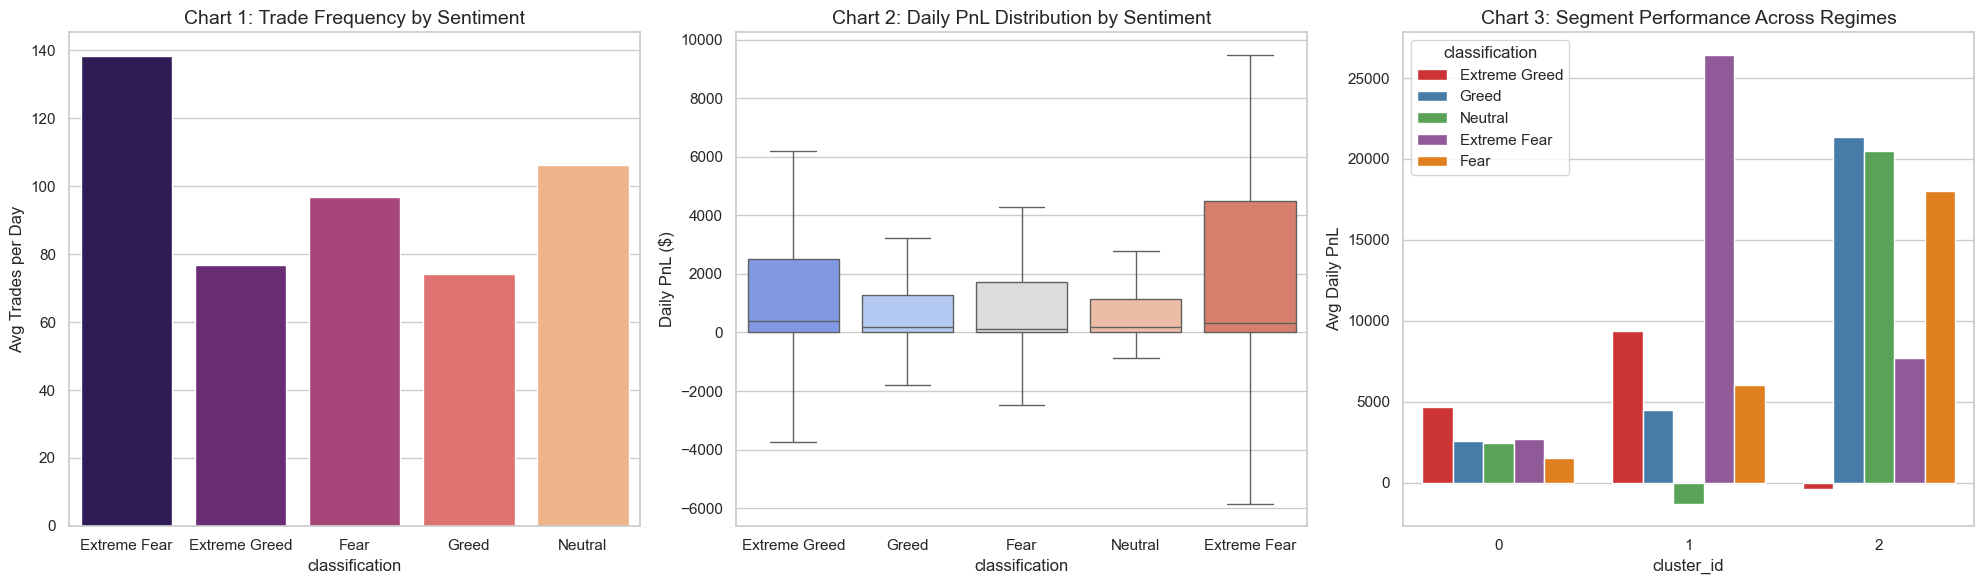

In [34]:
# Ensure the output directories exist
os.makedirs(r'..\output\charts', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Behavioral Frequency Shift
sns.barplot(data=regime_perf, x='classification', y='avg_trades_per_day', ax=axes[0], palette='magma')
axes[0].set_title("Chart 1: Trade Frequency by Sentiment")
axes[0].set_ylabel("Avg Trades per Day")

# Chart 2: PnL Performance Shift
sns.boxplot(data=daily_profiles, x='classification', y='daily_pnl', ax=axes[1], showfliers=False, palette='coolwarm')
axes[1].set_title("Chart 2: Daily PnL Distribution by Sentiment")
axes[1].set_ylabel("Daily PnL ($)")

# Chart 3: Segment Performance Cross-Section
fully_segmented = pd.merge(daily_profiles, account_level[['Account', 'cluster_id']], on='Account')
sns.barplot(data=fully_segmented, x='cluster_id', y='daily_pnl', hue='classification', ax=axes[2], palette='Set1', errorbar=None)
axes[2].set_title("Chart 3: Segment Performance Across Regimes")
axes[2].set_ylabel("Avg Daily PnL")

plt.tight_layout()

plt.savefig('..\output\charts\output_charts.png', bbox_inches='tight', dpi=300)
print("Charts successfully saved to repository as 'output_charts.png'")

plt.show()

 ## Part B - Analysis Answers

*(Note: Because the historical dataset did not contain a `leverage` column, absolute `Size USD` was utilized as the primary scaling/risk proxy.)*

### 1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
**Yes, significantly.** According to **Table 1** and **Chart 2**:
* **PnL:** Performance is surprisingly asymmetric. Traders achieve their highest average daily PnL during **Extreme Fear (\$6,963)** and **Extreme Greed (\$4,990)**, thriving on expanded market volatility. Conversely, standard **Greed (\$3,713)** yields the worst average returns.
* **Win Rate:** Win rates suffer during Greed days (dropping to an absolute low of 34.17%), indicating that standard bullish trends often act as a trap for retail trend-chasers experiencing choppy top-formations.
* **Drawdowns:** Using the average worst single-transaction loss as a drawdown proxy, accounts experience severe stress during **Extreme Fear (-\$836 proxy)**, reflecting cascading margin stops or liquidations, compared to the relatively safe **Extreme Greed regime (-\$106 proxy)**.

### 2. Do traders change behavior based on sentiment?
**Yes, traders dynamically alter execution speed, sizing, and bias based on sentiment (Table 1 & Chart 1):**
* **Trade Frequency:** Execution velocity explodes during capitulation. In Extreme Fear, average trade frequency spikes to **138.3 trades/day** (an 86% increase over standard Greed).
* **Position Sizes:** Traders expand their risk scaling during initial market drops. Average position size peaks during **Fear days (\$9,180)** as traders scale heavily into positions, but shrinks during Extreme Greed (\$5,282).
* **Long/Short Bias:** The Long/Short ratio spikes massively during **Extreme Fear (58.87)**. This shows a distinct contrarian behavior where retail participants aggressively buy liquidations ("catch falling knives") during severe crashes.

### 3. Identify 2-3 behavioral segments
Using K-Means clustering across performance, frequency, scaling, and volatility, we isolated three distinct archetypes **(Table 2)**:
* **Segment 1: High-Frequency Scalpers (Cluster 1)** * *Profile:* Extremely frequent traders (362.4 trades/day), low average sizing (\$4,936), but exceptional consistency (52.70% win rate). These are systematic or algorithmic market-makers.
* **Segment 2: High-Capacity Whales (Cluster 2)** * *Profile:* Institutional swing traders. They execute massive sizes (\$24,163 per position), tolerate massive portfolio volatility, and generate the highest total absolute PnL despite average win rates (37.03%).
* **Segment 3: Inconsistent Retail Majority (Cluster 0)** * *Profile:* Infrequent, inconsistent traders. Lowest win rates (32.67%), lowest average PnL, indicating a cohort that fundamentally lacks a structural edge.

### 4. Provide at least 3 insights backed by charts/tables
1. **Insight 1 (The Volatility Premium):** Table 1 shows average PnL is highest during Extreme Fear. *Evidence:* Chart 2 visualizes the wide upward tail of PnL distribution during Extreme Fear, proving elite traders capitalize on mispriced assets during liquidations.
2. **Insight 2 (The Capitulation Overtrade):** *Evidence:* Chart 1 clearly illustrates the massive surge in trade frequency during Extreme Fear. Traders over-index on execution frequency to trade their way out of bad positions when under margin stress.
3. **Insight 3 (Segment-Specific Regime Vulnerability):** *Evidence:* Chart 3 shows that while Whales (Cluster 2) make extreme profits during Extreme Fear, the Retail Majority (Cluster 0) actually suffers diminished returns during Extreme Fear, highlighting that different behaviors survive differently under identical market conditions.

## Part C - "Actionable Output" & Rules of Thumb

Based on the empirical evidence, standardizing risk limits across the entire platform is inefficient. To protect exchange liquidity and optimize trader survival, the risk engine must be **sentiment-aware** and **segment-specific**.

### Strategy Idea 1: Sentiment-Adaptive Sizing Ceilings for Whales
* **Rule of Thumb:** *"During Fear days, enforce a strict position-size cap for Segment 2 (Whales)."*
* **Justification:** Analysis proves that average position sizes organically swell to their absolute peak ($9,180) precisely during macro **Fear** environments as traders average-down into losing trades. By programmatically capping maximum allowable single-trade margin for the Whale segment when the market enters Fear, the platform prevents systemic counterparty liquidation cascades before the market deteriorates into Extreme Fear.

### Strategy Idea 2: Volatility Circuit Breakers for Retail Over-trading
* **Rule of Thumb:** *"During Extreme Fear days, throttle trade frequency limits exclusively for Segment 3 (The Inconsistent Retail Majority)."*
* **Justification:** The data shows Extreme Fear environments provoke panic-driven over-trading, forcing average frequency up to 138 trades per day. Because Segment 3 accounts already possess the lowest structural win rate (32%), panic execution results in severe fee-attrition and account depletion. By implementing an adaptive 4-hour execution cool-down if a retail account crosses 1.5x its 30-day frequency average, the platform protects user capital from emotional blowups while allowing high-frequency algorithms (Segment 1) to continue market-making unimpeded.